### Customer Segmentation

Goal: identify segments based on behavior + value, then profile them with
demographics and churn risk to produce actionable marketing personas.

We use ALL customers (including 2018 enrollees) for segmentation, since
this is about understanding the current customer base, not predicting churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load both files and combine (existing members + new 2018 enrollees)
existing = pd.read_csv("../data/processed/churn_model_data.csv")
new_members = pd.read_csv("../data/processed/new_members_2018.csv")

df = pd.concat([existing, new_members], ignore_index=True)
print(df.shape)
df.head()

(16737, 29)


,Loyalty Number,Country,Province,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,...,std_monthly_flights_2017,active_months_2017,redemption_rate_2017,flights_fall_2017,flights_spring_2017,flights_summer_2017,flights_winter_2017,months_since_last_flight_2017,churned,tenure_months
0,480934,Canada,Ontario,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,...,1.678744,7.0,0.012701,2.0,4.0,10.0,2.0,0.0,0,22
1,549612,Canada,Alberta,Male,College,NaN,Divorced,Star,3839.61,Standard,...,2.020726,8.0,0.021779,7.0,9.0,9.0,6.0,1.0,0,21
2,429460,Canada,British Columbia,Male,College,NaN,Single,Star,3839.75,Standard,...,1.370689,7.0,0.016291,4.0,6.0,3.0,3.0,1.0,1,41
3,608370,Canada,Ontario,Male,College,NaN,Single,Star,3839.75,Standard,...,1.758098,9.0,0.025892,5.0,10.0,5.0,4.0,0.0,0,58
4,530508,Canada,Quebec,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,...,1.443376,4.0,0.000000,2.0,2.0,4.0,3.0,1.0,0,38


### 1. Select features for clustering

We use behavioral + value features only. Demographics are kept aside
for profiling afterward.

In [2]:
cluster_features = [
    'CLV',
    'tenure_months',
    'total_flights_2017',
    'total_distance_2017',
    'total_points_accum_2017',
    'total_points_redeemed_2017',
    'redemption_rate_2017',
    'active_months_2017',
    'months_since_last_flight_2017',
    'avg_monthly_flights_2017'
]

X_cluster = df[cluster_features].copy()
print(X_cluster.isna().sum())
X_cluster.describe()

CLV                              0
tenure_months                    0
total_flights_2017               0
total_distance_2017              0
total_points_accum_2017          0
total_points_redeemed_2017       0
redemption_rate_2017             0
active_months_2017               0
months_since_last_flight_2017    0
avg_monthly_flights_2017         0
dtype: int64


,CLV,tenure_months,total_flights_2017,total_distance_2017,total_points_accum_2017,total_points_redeemed_2017,redemption_rate_2017,active_months_2017,months_since_last_flight_2017,avg_monthly_flights_2017
count,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000
mean,7988.896536,27.411185,13.339428,19974.650774,19974.650774,336.612774,0.014234,4.885643,3.018283,1.103685
std,6860.982280,22.093129,10.020047,15525.734047,15525.734047,469.568136,0.027644,3.510527,4.680165,0.823125
min,1898.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3980.840000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5780.180000,25.000000,15.000000,21739.000000,21739.000000,0.000000,0.000000,6.000000,0.000000,1.250000
75%,8940.580000,47.000000,21.000000,31555.000000,31555.000000,561.000000,0.021821,8.000000,3.000000,1.750000
max,83325.380000,68.000000,61.000000,90564.000000,90564.000000,3427.000000,1.059603,20.000000,12.000000,3.500000


### 2. Scale features (K-Means is distance-based, so scale matters a lot)

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
X_scaled = pd.DataFrame(X_scaled, columns=cluster_features)
X_scaled.describe()

,CLV,tenure_months,total_flights_2017,total_distance_2017,total_points_accum_2017,total_points_redeemed_2017,redemption_rate_2017,active_months_2017,months_since_last_flight_2017,avg_monthly_flights_2017
count,1.673700e+04,1.673700e+04,1.673700e+04,1.673700e+04,1.673700e+04,1.673700e+04,1.673700e+04,16737.000000,16737.000000,1.673700e+04
mean,2.037764e-17,2.717018e-17,-1.086807e-16,-5.434037e-17,-5.434037e-17,1.358509e-17,-4.075527e-17,0.000000,0.000000,-8.151055e-17
std,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030,1.000030,1.000030e+00
min,-8.877837e-01,-1.240748e+00,-1.331314e+00,-1.286590e+00,-1.286590e+00,-7.168775e-01,-5.149340e-01,-1.391754,-0.644929,-1.340887e+00
25%,-5.841986e-01,-1.014426e+00,-1.331314e+00,-1.286590e+00,-1.286590e+00,-7.168775e-01,-5.149340e-01,-1.391754,-0.644929,-1.340887e+00
50%,-3.219339e-01,-1.091406e-01,1.657300e-01,1.136437e-01,1.136437e-01,-7.168775e-01,-5.149340e-01,0.317443,-0.644929,1.777608e-01
75%,1.387137e-01,8.866739e-01,7.645475e-01,7.459032e-01,7.459032e-01,4.778730e-01,2.744557e-01,0.887175,-0.003907,7.852198e-01
max,1.098075e+01,1.837224e+00,4.756664e+00,4.546739e+00,4.546739e+00,6.581536e+00,3.781660e+01,4.305567,1.919160,2.911326e+00


### 3. Find optimal number of clusters (Elbow method + Silhouette score)

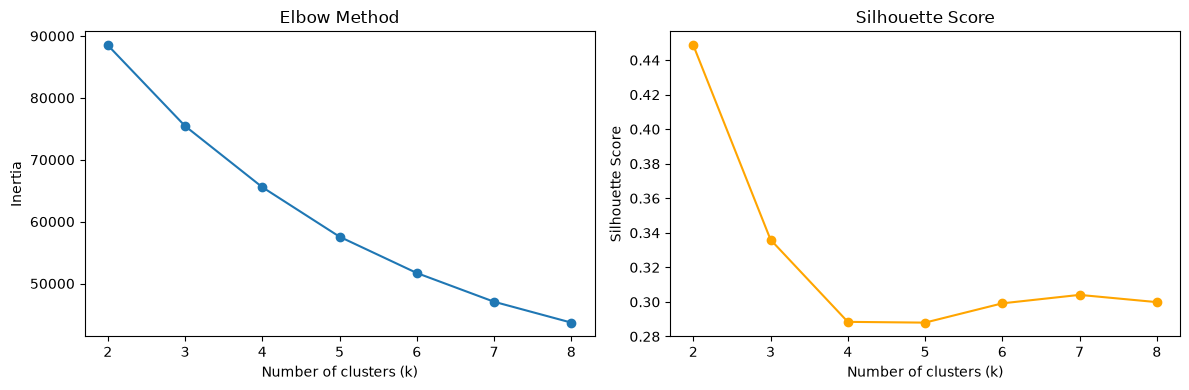

k=2: silhouette=0.449
k=3: silhouette=0.336
k=4: silhouette=0.288
k=5: silhouette=0.288
k=6: silhouette=0.299
k=7: silhouette=0.304
k=8: silhouette=0.300


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), sil_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig("../outputs/cluster_selection.png", dpi=150)
plt.show()

for k, s in zip(k_range, sil_scores):
    print(f"k={k}: silhouette={s:.3f}")

### 4. Fit final K-Means model with k=4

We choose k=4 over the silhouette-optimal k=2 because k=2 only separates
"active" vs "inactive" customers — too coarse for actionable marketing
segments. k=4 balances statistical validity with business interpretability.

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['segment'] = kmeans.fit_predict(X_scaled)

print(df['segment'].value_counts().sort_index())
print("\nSilhouette score:", round(silhouette_score(X_scaled, df['segment']), 3))

segment
0    4556
1    5081
2    2130
3    4970
Name: count, dtype: int64

Silhouette score: 0.288


### 5. Profile each segment on clustering features (means)

In [6]:
segment_profile = df.groupby('segment')[cluster_features].mean().round(1)
segment_profile['count'] = df['segment'].value_counts().sort_index()
segment_profile

,CLV,tenure_months,total_flights_2017,total_distance_2017,total_points_accum_2017,total_points_redeemed_2017,redemption_rate_2017,active_months_2017,months_since_last_flight_2017,avg_monthly_flights_2017,count
segment,,,,,,,,,,,
0,8075.0,39.1,24.8,38157.5,38157.5,499.7,0.0,8.5,0.4,2.0,4556
1,8112.2,11.4,0.6,916.0,916.0,3.9,0.0,0.3,8.2,0.1,5081
2,7814.7,32.1,15.5,22069.6,22069.6,1140.1,0.1,6.1,0.9,1.3,2130
3,7858.6,31.1,14.9,21892.8,21892.8,182.8,0.0,5.8,1.0,1.2,4970


### 6. Overlay churn rate and demographics on each segment

In [7]:
# Churn rate by segment (use only existing members, since new 2018 enrollees have no churn label context)
existing_with_seg = df[df['Enrollment Year'] != 2018]
print("Churn rate by segment:")
print(existing_with_seg.groupby('segment')['churned'].mean().round(3))

print("\nLoyalty Card distribution by segment:")
print(pd.crosstab(df['segment'], df['Loyalty Card'], normalize='index').round(2))

print("\nEducation distribution by segment:")
print(pd.crosstab(df['segment'], df['Education'], normalize='index').round(2))

print("\nMarital Status distribution by segment:")
print(pd.crosstab(df['segment'], df['Marital Status'], normalize='index').round(2))

Churn rate by segment:
segment
0    0.040
1    0.643
2    0.074
3    0.086
Name: churned, dtype: float64

Loyalty Card distribution by segment:
Loyalty Card  Aurora  Nova  Star
segment                         
0               0.21  0.34  0.45
1               0.21  0.34  0.45
2               0.21  0.33  0.46
3               0.20  0.34  0.47

Education distribution by segment:
Education  Bachelor  College  Doctor  High School or Below  Master
segment                                                           
0              0.62     0.25    0.05                  0.05    0.03
1              0.64     0.25    0.04                  0.05    0.03
2              0.61     0.26    0.05                  0.05    0.03
3              0.63     0.26    0.04                  0.04    0.03

Marital Status distribution by segment:
Marital Status  Divorced  Married  Single
segment                                  
0                   0.14     0.59    0.27
1                   0.15     0.58    0.27
2          

### 7. Visualize segments — CLV vs Recency, colored by segment

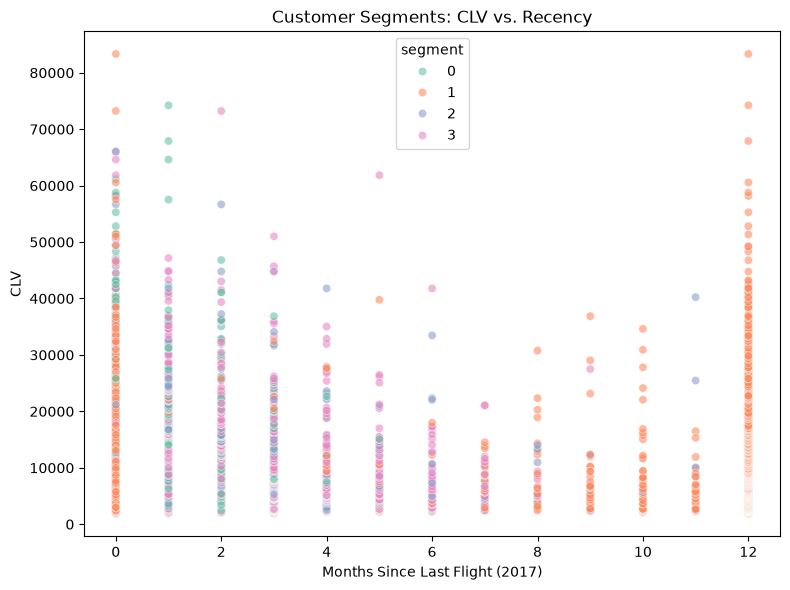

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='months_since_last_flight_2017', y='CLV', hue='segment', palette='Set2', alpha=0.6)
plt.title('Customer Segments: CLV vs. Recency')
plt.xlabel('Months Since Last Flight (2017)')
plt.ylabel('CLV')
plt.tight_layout()
plt.savefig("../outputs/segments_clv_recency.png", dpi=150)
plt.show()

### 8. Visualize segment sizes and average CLV

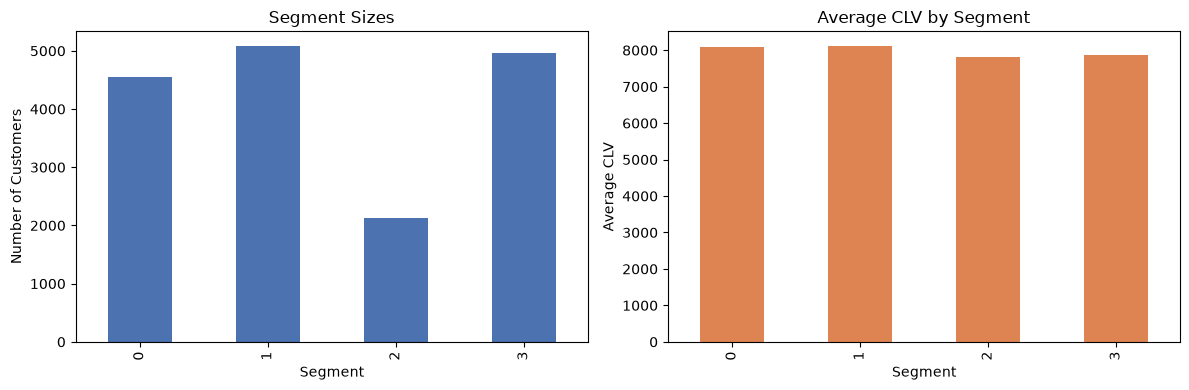

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

df['segment'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Segment Sizes')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Number of Customers')

df.groupby('segment')['CLV'].mean().plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Average CLV by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Average CLV')

plt.tight_layout()
plt.savefig("../outputs/segment_overview.png", dpi=150)
plt.show()

In [10]:
pd.set_option('display.width', 250)
segment_profile

,CLV,tenure_months,total_flights_2017,total_distance_2017,total_points_accum_2017,total_points_redeemed_2017,redemption_rate_2017,active_months_2017,months_since_last_flight_2017,avg_monthly_flights_2017,count
segment,,,,,,,,,,,
0,8075.0,39.1,24.8,38157.5,38157.5,499.7,0.0,8.5,0.4,2.0,4556
1,8112.2,11.4,0.6,916.0,916.0,3.9,0.0,0.3,8.2,0.1,5081
2,7814.7,32.1,15.5,22069.6,22069.6,1140.1,0.1,6.1,0.9,1.3,2130
3,7858.6,31.1,14.9,21892.8,21892.8,182.8,0.0,5.8,1.0,1.2,4970


In [11]:
pd.set_option('display.width', 250)
pd.set_option('display.max_columns', None)
print(segment_profile)

            CLV  tenure_months  total_flights_2017  total_distance_2017  total_points_accum_2017  total_points_redeemed_2017  redemption_rate_2017  active_months_2017  months_since_last_flight_2017  avg_monthly_flights_2017  count
segment                                                                                                                                                                                                                               
0        8075.0           39.1                24.8              38157.5                  38157.5                       499.7                   0.0                 8.5                            0.4                       2.0   4556
1        8112.2           11.4                 0.6                916.0                    916.0                         3.9                   0.0                 0.3                            8.2                       0.1   5081
2        7814.7           32.1                15.5              22069.6     

In [12]:
seg1 = df[df['segment'] == 1]
print("Segment 1 - enrolled in 2018 (new members):", (seg1['Enrollment Year'] == 2018).sum())
print("Segment 1 - enrolled before 2018 (existing, dormant):", (seg1['Enrollment Year'] != 2018).sum())

# Churn rate split
seg1_existing = seg1[seg1['Enrollment Year'] != 2018]
print("\nChurn rate among Segment 1 existing members:", seg1_existing['churned'].mean().round(3))

Segment 1 - enrolled in 2018 (new members): 2767
Segment 1 - enrolled before 2018 (existing, dormant): 2314

Churn rate among Segment 1 existing members: 0.643


### 9. Refine Segment 1 into New Members vs. Lapsed/Critical

Segment 1 mixes two very different groups: brand-new 2018 enrollees
(no behavior history yet) and existing members who have genuinely gone
dormant (64.3% churn). These require different retention treatments.

In [13]:
def refine_segment(row):
    if row['segment'] == 1:
        if row['Enrollment Year'] == 2018:
            return '1a_New_Member'
        else:
            return '1b_Lapsed_Critical'
    else:
        return f"segment_{row['segment']}"

df['final_segment'] = df.apply(refine_segment, axis=1)
print(df['final_segment'].value_counts())

final_segment
segment_3             4970
segment_0             4556
1a_New_Member         2767
1b_Lapsed_Critical    2314
segment_2             2130
Name: count, dtype: int64


In [14]:
# Save the final segmented dataset for use in the dashboard and report
df.to_csv("../data/processed/customer_segments_final.csv", index=False)
print("Saved:", df.shape)

Saved: (16737, 31)


### 10. Map each segment to a recommended retention action

This encodes the business logic table into the dataset, so the dashboard
can show a specific recommended action per customer.

In [15]:
action_map = {
    'segment_0': 'Loyalty Reward: Tier upgrade / exclusive perk (protect top customer)',
    '1a_New_Member': 'Onboarding Series: Day 7/30/60 engagement nudges',
    '1b_Lapsed_Critical': 'Urgent Win-Back: Bonus points offer + personal outreach',
    'segment_2': 'Cross-Sell: Partner redemption offers (quarterly)',
    'segment_3': 'Points Activation: "Use it or lose it" redemption nudge'
}

priority_map = {
    '1b_Lapsed_Critical': 'Critical',
    'segment_3': 'Medium',
    '1a_New_Member': 'Medium',
    'segment_2': 'Low',
    'segment_0': 'Low (Retain VIP)'
}

df['recommended_action'] = df['final_segment'].map(action_map)
df['priority'] = df['final_segment'].map(priority_map)

df[['Loyalty Number', 'final_segment', 'CLV', 'months_since_last_flight_2017', 'recommended_action', 'priority']].head(10)

,Loyalty Number,final_segment,CLV,months_since_last_flight_2017,recommended_action,priority
0,480934,segment_3,3839.14,0.0,"Points Activation: ""Use it or lose it"" redempt...",Medium
1,549612,segment_0,3839.61,1.0,Loyalty Reward: Tier upgrade / exclusive perk ...,Low (Retain VIP)
2,429460,segment_3,3839.75,1.0,"Points Activation: ""Use it or lose it"" redempt...",Medium
3,608370,segment_0,3839.75,0.0,Loyalty Reward: Tier upgrade / exclusive perk ...,Low (Retain VIP)
4,530508,segment_3,3842.79,1.0,"Points Activation: ""Use it or lose it"" redempt...",Medium
5,193662,segment_0,3844.57,0.0,Loyalty Reward: Tier upgrade / exclusive perk ...,Low (Retain VIP)
6,927943,segment_2,3857.95,1.0,Cross-Sell: Partner redemption offers (quarterly),Low
7,188893,segment_0,3861.49,1.0,Loyalty Reward: Tier upgrade / exclusive perk ...,Low (Retain VIP)
8,852392,segment_0,3861.49,0.0,Loyalty Reward: Tier upgrade / exclusive perk ...,Low (Retain VIP)
9,866307,segment_2,3861.49,1.0,Cross-Sell: Partner redemption offers (quarterly),Low


In [16]:
# Save final dataset with actions - this feeds the dashboard
df.to_csv("../data/processed/customer_segments_final.csv", index=False)
print("Saved final dataset with recommendations:", df.shape)
print("\nPriority distribution:")
print(df['priority'].value_counts())

Saved final dataset with recommendations: (16737, 33)

Priority distribution:
priority
Medium              7737
Low (Retain VIP)    4556
Critical            2314
Low                 2130
Name: count, dtype: int64
